# 03 — SAM 3 video tracking

**Objetivo:** propagar máscaras frame a frame manteniendo **identidades consistentes** (el robot #1 sigue siendo robot #1 en todos los frames).

**Diferencia con 01/02:**
- 01 y 02: cada frame es independiente, los `obj_id` no tienen relación entre frames.
- 03: SAM 3 video — los `obj_id` se mantienen estables a lo largo del clip. Esto permite trayectorias, conteo consistente, asociación frame a frame.

**Flujo:**
1. Carga SAM 3
2. Extrae **20 frames** de un clip corto (~10 s, 1 frame cada 0.5 s)
3. Crea **una sola sesión** con todos los frames
4. Aplica prompts: `"orange ball"` y `"robot"` (ambos en frame 0, se propagan)
5. Corre `model(session, frame_idx=N)` para cada frame
6. Salidas:
   - Grid estático: 4 frames muestra con tracking overlay (color consistente por obj_id)
   - Video mp4 con tracking continuo guardado en `outputs/`
   - Plot de trayectorias (centroides obj_id × tiempo)

**Tiempo estimado:** ~7 min (40 inferencias × ~11 s).

**Output mp4:** `outputs/tracked_<videoname>.mp4` (gitignored, vive en volume).

## 1. Imports

In [1]:
import sys, time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple
from collections import defaultdict

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import decord
import imageio
from transformers import AutoProcessor, AutoModel

WORKSPACE = Path('/workspace')
REPO = WORKSPACE / 'FutBotMX-UAQTeam'
SAM3_PATH = REPO / 'assets' / 'sam3'
DATA = REPO / 'data' / 'raw'
OUTPUTS = Path('outputs')  # relative to notebook (fase_0/03_sam3_video_tracking/outputs)
OUTPUTS.mkdir(exist_ok=True)

print('Python:', sys.version.split()[0], '| torch:', torch.__version__)
print('OUTPUTS:', OUTPUTS.resolve())

Python: 3.11.13 | torch: 2.12.0+cpu
OUTPUTS: /workspace/FutBotMX-UAQTeam/notebooks/fase_0/03_sam3_video_tracking/outputs


## 2. Cargar SAM 3

In [2]:
t0 = time.time()
processor = AutoProcessor.from_pretrained(str(SAM3_PATH))
model = AutoModel.from_pretrained(
    str(SAM3_PATH),
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
)
model.eval()
print(f'Carga: {time.time()-t0:.1f}s')

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Carga: 10.1s


## 3. Extraer clip de 20 frames

Tomamos un video y muestreamos 20 frames evenly spaced en sus primeros 10 segundos (1 frame cada 0.5 s). Esto es suficiente pa' demo de tracking sin tardar demasiado.

In [3]:
VIDEO_PATH = sorted((DATA / '17Abril' / 'Cámaras').glob('*.MOV'))[0]
print('Video:', VIDEO_PATH.name)

vr = decord.VideoReader(str(VIDEO_PATH))
fps = vr.get_avg_fps()
total = len(vr)

N_FRAMES = 20
CLIP_DURATION_S = 10.0
max_idx = min(int(CLIP_DURATION_S * fps), total - 1)
FRAME_INDICES = list(np.linspace(0, max_idx, N_FRAMES, dtype=int))
arr = vr.get_batch(FRAME_INDICES).asnumpy()  # (N, H, W, 3)
frames_pil = [Image.fromarray(a) for a in arr]
H, W = arr.shape[1], arr.shape[2]

print(f'  total frames: {total}, fps: {fps:.0f}')
print(f'  clip indices: {FRAME_INDICES}')
print(f'  N frames extraídos: {len(frames_pil)}, tamaño: {W}x{H}')

Video: IMG_9779.MOV


  total frames: 1044, fps: 30
  clip indices: [np.int64(0), np.int64(15), np.int64(31), np.int64(47), np.int64(62), np.int64(78), np.int64(94), np.int64(110), np.int64(125), np.int64(141), np.int64(157), np.int64(173), np.int64(188), np.int64(204), np.int64(220), np.int64(236), np.int64(251), np.int64(267), np.int64(283), np.int64(299)]
  N frames extraídos: 20, tamaño: 1920x1080


## 4. Sesión + prompts (frame 0)

**Patrón tracking SAM 3:**
1. `init_video_session(video=lista_de_frames)` — preload los frames
2. `add_text_prompt(session, text="...")` aplica el prompt en frame 0
3. Repetir 2 pa' cada clase
4. `model(inference_session=session, frame_idx=N)` propaga al frame N manteniendo obj_ids

Los `obj_id`s asignados en frame 0 se mantienen consistentes a través del clip.

In [4]:
PROMPTS = ['orange ball', 'robot']

session = processor.init_video_session(
    video=frames_pil,
    inference_device='cpu',
    dtype=torch.bfloat16,
)
for p in PROMPTS:
    session = processor.add_text_prompt(session, text=p)
    print(f'  added prompt: "{p}"')

print(f'\nSession objetos pre-tracking: {session.get_obj_num()}')

  added prompt: "orange ball"
  added prompt: "robot"

Session objetos pre-tracking: 0


## 5. Inferencia frame a frame

Por cada frame: `model(session, frame_idx=N)` → trae máscaras de los obj_ids tracked.

Anotamos qué clase corresponde a cada obj_id mirando los object_ids en frame 0 (cuando agregamos los prompts en orden, los obj_ids del primer prompt salen primero).

In [5]:
# results[frame_idx] = {obj_id: (mask_np_bool, score)}
results = []
all_object_ids_seen = set()
t_start = time.time()

for i in range(len(frames_pil)):
    t0 = time.time()
    with torch.no_grad():
        out = model(inference_session=session, frame_idx=i)
    masks_per_obj = {}
    for oid in out.object_ids:
        m = out.obj_id_to_mask[oid].detach().cpu().float().numpy()
        if m.ndim == 4: m = m[0, 0]
        elif m.ndim == 3: m = m[0]
        s = float(out.obj_id_to_score.get(oid, 0.0))
        masks_per_obj[int(oid)] = (m > 0.0, s)
        all_object_ids_seen.add(int(oid))
    results.append(masks_per_obj)
    print(f'  frame {i:2d} (orig idx={FRAME_INDICES[i]:4d}): {len(masks_per_obj)} obj_ids tracked, [{time.time()-t0:.1f}s]')

print(f'\nTotal: {time.time()-t_start:.1f}s  |  obj_ids únicos vistos: {sorted(all_object_ids_seen)}')

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


  frame  0 (orig idx=   0): 4 obj_ids tracked, [12.9s]


  frame  1 (orig idx=  15): 4 obj_ids tracked, [12.5s]


  frame  2 (orig idx=  31): 4 obj_ids tracked, [13.4s]


  frame  3 (orig idx=  47): 4 obj_ids tracked, [14.6s]


...

  frame 15 (orig idx= 236): 4 obj_ids tracked, [18.0s]


  frame 16 (orig idx= 251): 4 obj_ids tracked, [17.6s]


  frame 17 (orig idx= 267): 4 obj_ids tracked, [17.7s]


  frame 18 (orig idx= 283): 4 obj_ids tracked, [17.6s]


  frame 19 (orig idx= 299): 4 obj_ids tracked, [17.7s]

Total: 336.4s  |  obj_ids únicos vistos: [0, 1, 2, 3]


## 6. Asignar clase a cada obj_id

Como SAM 3 video session no exporta directamente el mapeo `obj_id → prompt_que_lo_creó`, asumimos que el orden de los `add_text_prompt` corresponde al orden de los `obj_id`s. Eso suele ser cierto: los obj_ids del primer prompt salen primero.

Si tu modelo detectó N_a objetos para `"orange ball"` y N_b para `"robot"`, los obj_ids más bajos son ball, los siguientes son robot.

In [6]:
# Heurística: revisar object_ids del frame 0 y asumir orden
frame0_objects = list(results[0].keys())
print(f'obj_ids en frame 0: {sorted(frame0_objects)}')

# Re-ejecutar prompts por separado en frame 0 pa' saber cuántos de cada uno
# (más confiable que asumir orden)
tmp_session = processor.init_video_session(video=[frames_pil[0]], inference_device='cpu', dtype=torch.bfloat16)
tmp_session = processor.add_text_prompt(tmp_session, text=PROMPTS[0])
with torch.no_grad():
    out0 = model(inference_session=tmp_session, frame_idx=0)
n_class0 = len(out0.object_ids)
print(f'  "{PROMPTS[0]}" detecta {n_class0} obj(s) en frame 0')

# Mapeo obj_id -> class_name (asumiendo que los primeros n_class0 obj_ids son del primer prompt)
sorted_obj_ids = sorted(all_object_ids_seen)
obj_to_class = {}
for i, oid in enumerate(sorted_obj_ids):
    obj_to_class[oid] = PROMPTS[0] if i < n_class0 else PROMPTS[1]

print(f'\nMapeo obj_id → clase:')
for oid, cls in obj_to_class.items():
    print(f'  obj {oid} → "{cls}"')

obj_ids en frame 0: [0, 1, 2, 3]


  "orange ball" detecta 1 obj(s) en frame 0

Mapeo obj_id → clase:
  obj 0 → "orange ball"
  obj 1 → "robot"
  obj 2 → "robot"
  obj 3 → "robot"


## 7. Asignar color consistente por obj_id

Cada obj_id mantiene su color a lo largo de todos los frames — eso es la clave visual del tracking.

In [7]:
cmap = plt.get_cmap('tab20')
obj_to_color = {}
for i, oid in enumerate(sorted_obj_ids):
    obj_to_color[oid] = np.array(cmap(i % 20)[:3])

print(f'{len(obj_to_color)} obj_ids con color asignado')

4 obj_ids con color asignado


## 8. Visualización — 4 frames muestra

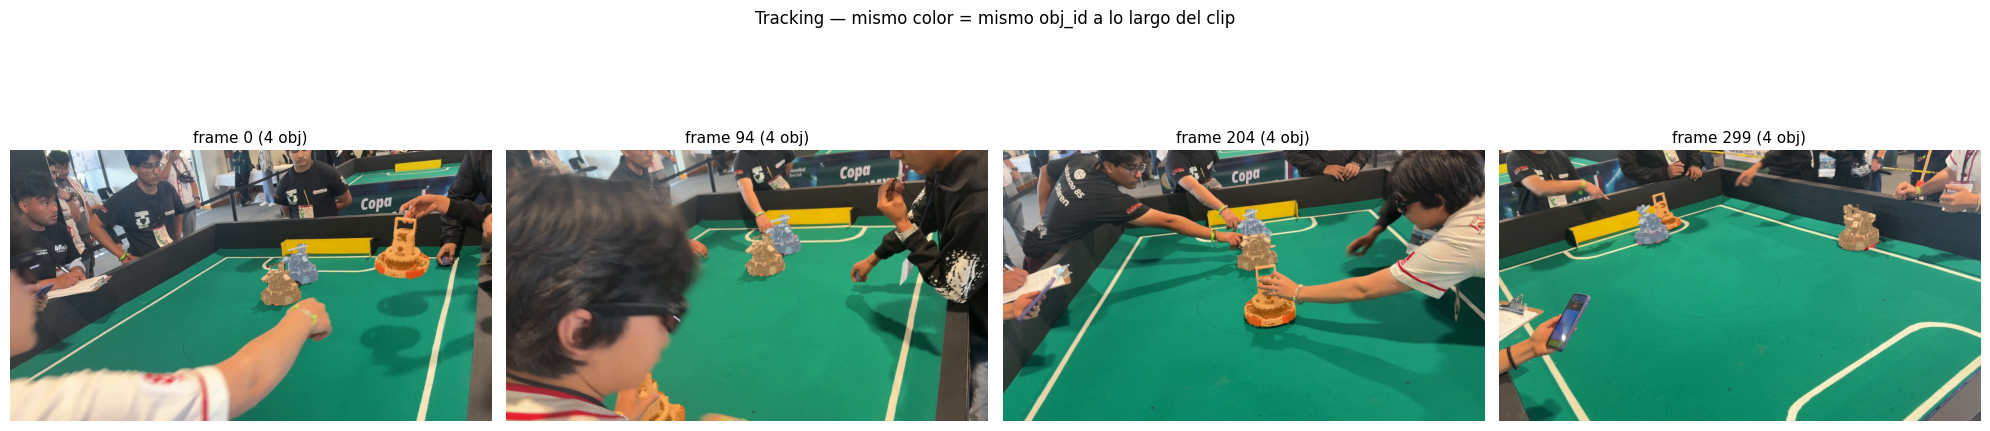

In [8]:
def overlay_tracked(image_pil, masks_per_obj, obj_to_color, alpha=0.55):
    img = np.array(image_pil).astype(np.float32) / 255.0
    H, W, _ = img.shape
    overlay = img.copy()
    for oid, (mask, _) in masks_per_obj.items():
        if mask.shape != (H, W):
            mask = np.array(Image.fromarray(mask.astype(np.uint8)*255).resize((W, H), Image.NEAREST)) > 0
        c = obj_to_color[oid]
        overlay[mask] = (1 - alpha) * overlay[mask] + alpha * c
    return overlay

show_indices = [0, len(frames_pil)//3, 2*len(frames_pil)//3, len(frames_pil)-1]
fig, axes = plt.subplots(1, len(show_indices), figsize=(5*len(show_indices), 5))
for ax, idx in zip(axes, show_indices):
    ax.imshow(overlay_tracked(frames_pil[idx], results[idx], obj_to_color))
    n_obj = len(results[idx])
    ax.set_title(f'frame {FRAME_INDICES[idx]} ({n_obj} obj)', fontsize=11)
    ax.axis('off')
plt.suptitle('Tracking — mismo color = mismo obj_id a lo largo del clip', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9. Guardar video mp4 con tracking overlay

El archivo va a `outputs/tracked_<videoname>.mp4` dentro del notebook folder. Está gitignored (no sube a GitHub) pero vive en el volume y compas lo descargan desde Jupyter.

In [9]:
output_mp4 = OUTPUTS / f'tracked_{VIDEO_PATH.stem}.mp4'
writer = imageio.get_writer(
    str(output_mp4),
    fps=int(fps / max(1, FRAME_INDICES[1] - FRAME_INDICES[0])),
    codec='libx264',
    quality=8,
)
for i, img in enumerate(frames_pil):
    over = overlay_tracked(img, results[i], obj_to_color)
    over_u8 = (over * 255).clip(0, 255).astype(np.uint8)
    writer.append_data(over_u8)
writer.close()

size_mb = output_mp4.stat().st_size / 1e6
print(f'Guardado: {output_mp4.resolve()} ({size_mb:.1f} MB)')

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1920, 1080) to (1920, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


[rawvideo @ 0x823cfc0] Stream #0: not enough frames to estimate rate; consider increasing probesize


Guardado: /workspace/FutBotMX-UAQTeam/notebooks/fase_0/03_sam3_video_tracking/outputs/tracked_IMG_9779.mp4 (13.1 MB)


## 10. Trayectorias — centroide de cada obj_id en el tiempo

Pa' cada obj_id, calculamos el centroide de su máscara en cada frame y graficamos su trayectoria. **Esto es directamente lo que vale tracking sobre re-detection: ves rutas continuas, no puntos sueltos.**

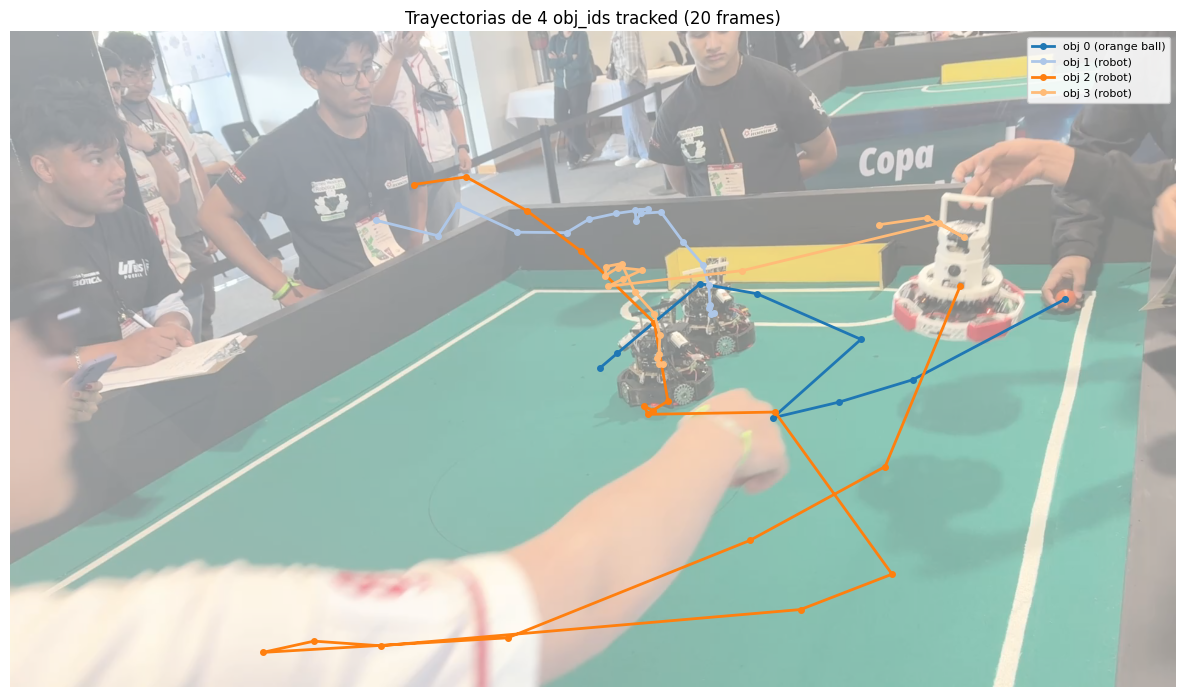

In [10]:
# trajectories[obj_id] = lista de (frame_idx, cx, cy) o None si no había máscara ese frame
trajectories = defaultdict(list)
for fi, masks_per_obj in enumerate(results):
    for oid in sorted_obj_ids:
        if oid in masks_per_obj:
            mask, _ = masks_per_obj[oid]
            if mask.shape != (H, W):
                mask = np.array(Image.fromarray(mask.astype(np.uint8)*255).resize((W, H), Image.NEAREST)) > 0
            ys, xs = np.where(mask)
            if len(xs) > 0:
                cx, cy = xs.mean(), ys.mean()
                trajectories[oid].append((fi, cx, cy))

# Plot — fondo: primer frame; encima: trayectorias
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(frames_pil[0], alpha=0.5)
for oid, traj in trajectories.items():
    if len(traj) < 2: continue
    xs = [t[1] for t in traj]
    ys = [t[2] for t in traj]
    c = obj_to_color[oid]
    ax.plot(xs, ys, '-o', color=c, markersize=4, linewidth=2, label=f'obj {oid} ({obj_to_class.get(oid, "?")})')
ax.set_title(f'Trayectorias de {len(trajectories)} obj_ids tracked ({len(frames_pil)} frames)')
ax.axis('off')
ax.legend(loc='upper right', fontsize=8, framealpha=0.85)
plt.tight_layout()
plt.show()

## 11. Estadística — presencia de cada obj_id por frame

Un obj_id puede salir de cuadro o quedar oculto en algunos frames. Aquí vemos en cuántos frames cada uno fue rastreado.

In [11]:
print(f'{"obj_id":>6s}  {"clase":12s}  {"frames":>8s}  {"cobertura":>12s}')
print('-' * 50)
for oid in sorted_obj_ids:
    n_frames_with = sum(1 for r in results if oid in r)
    pct = 100 * n_frames_with / len(results)
    cls = obj_to_class.get(oid, '?')
    print(f'{oid:>6d}  {cls:12s}  {n_frames_with:>4d}/{len(results):<3d}  {pct:>8.1f}%')

obj_id  clase           frames     cobertura
--------------------------------------------------
     0  orange ball     20/20      100.0%
     1  robot           20/20      100.0%
     2  robot           20/20      100.0%
     3  robot           20/20      100.0%


## 12. Notas + próximos pasos

**Lo que valida este notebook:**
- ✅ SAM 3 video session mantiene `obj_id`s consistentes entre frames (esencial pa' tracking).
- ✅ Trayectorias se ven continuas (movimiento real, no puntos sueltos).
- ✅ Output mp4 utilizable directamente pa' demo/análisis.

**Limitaciones observadas:**
- Tiempo en CPU: ~11 s/frame — para video de 1000 frames sería ~3 horas. **Necesita GPU.**
- Cobertura: algunos obj_ids no se detectan en todos los frames (pelota oculta, robot fuera de cuadro).
- Mapeo `obj_id → clase`: heurístico (orden de prompts). Si SAM 3 v4 expone esto directo, mejor.

**Próximos:**
- `04_sam3_video_tracking_full.ipynb` — correr tracking sobre clip completo en GPU pod (5090) y medir speedup vs CPU.
- Fase 1: usar estos tracks como base pa' entrenar clasificador ally/enemy sobre features extraídos por obj_id.